# Descripción del Conjunto de Datos
El dataset contiene información sobre los clientes de un banco y sus transacciones financieras durante un período de 12 meses. Incluye datos sobre facturación, transacciones, actividad con tarjetas de crédito/débito y características demográficas de los clientes.

## Resumen de los Atributos
- Datos Demográficos: Edad, renta, región de residencia, antigüedad en el banco.
- Uso de Productos Bancarios: Número de cuentas, tarjetas de crédito (TC), tarjetas de débito (TD), créditos hipotecarios.
- Transacciones y Facturación: Monto facturado (Fac_T01 - Fac_T12), número de transacciones (Txs_T01 - Txs_T12), uso de líneas de crédito (UsoL1_T12, UsoL2_T12).
- Actividad Mensual: Indicadores de uso activo de la tarjeta (FlgAct_T01 - FlgAct_T12).
Objetivo del Análisis

El propósito de este análisis es predecir el churn (deserción) de clientes bancarios. Para ello, se estudian patrones de gasto, transacciones y actividad con el fin de identificar señales tempranas de abandono. Esta información permitirá al banco diseñar estrategias de retención y fidelización de clientes.

In [299]:
def get_metricas(y_test, y_pred):
    # matriz de confusion
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    plt.title('Matriz de Confusión')
    plt.xlabel('Predicción')
    plt.ylabel('Valor Real')
    plt.show()
    
    # reporte
    print("-------------------------------------------------")
    print(classification_report(y_test, y_pred))
    print("-------------------------------------------------")
    
    # curva de roc y area bajo la curva
    print("Curva de roc y area bajo la curva")
    print(roc_auc_score(y_test, y_pred))

In [301]:
def evaluate_metrics(yt, yp):
    results_pos = {}
    results_pos['accuracy'] = accuracy_score(yt, yp)
    precision, recall, f_beta, _ = precision_recall_fscore_support(yt, yp, average='binary')
    results_pos['recall'] = recall
    results_pos['precision'] = precision
    results_pos['f1score'] = f_beta
    return results_pos

In [303]:
def plot_decision_tree(model, feature_names):
    plt.subplots(figsize=(25, 20)) 
    tree.plot_tree(model, 
                       feature_names=feature_names,  
                       filled=True)
    plt.show()

In [305]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from imblearn.over_sampling import RandomOverSampler, SMOTE

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, precision_recall_fscore_support, f1_score

from sklearn import tree
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

In [307]:
import warnings
warnings.filterwarnings("ignore")

In [7]:
# Leemos los datos
data = pd.read_csv(r'data/Monopoly.csv', sep=',', skiprows=1)

# copia de los datos para mantener una version sin cambios
df = data.copy()

# revisar los datos, primeras 5 filas
df.head()

,Id,Subsegmento,Sexo,Region,Edad,Renta,Antiguedad,Internauta,Adicional,Dualidad,...,PagoNac_T01,PagoInt_T01,EeccNac_T01,EeccInt_T01,UsoL1_T01,UsoL2_T01,UsoLI_T01,IndRev_T01,target,Unnamed: 574
0,1,160,M,13.0,43,NaN,130,1,1,0,...,33000,0.0,1099866.0,0.0,1099866.0,15080,0.0,R,0,NaN
1,2,160,H,13.0,46,143640.0,69,1,0,0,...,300000,0.0,214592.0,0.0,214592.0,83596,0.0,R,0,NaN
2,3,170,H,13.0,45,929106.0,24,1,1,0,...,216676,0.0,0.0,0.0,7400.0,0,0.0,T,0,NaN
3,4,151,H,13.0,46,172447.0,134,0,1,0,...,60000,0.0,272762.0,0.0,272762.0,10591,0.0,R,0,NaN
4,5,170,H,13.0,46,805250.0,116,0,1,1,...,272925,0.0,249562.0,0.0,75339.0,377782,0.0,R,0,NaN


In [9]:
# variables categoricas a eliminar IndRev12-01
deleted = df.select_dtypes(include='object').iloc[:, 1:]
df = df.drop(deleted, axis=1)
# Borramos ID y Unnamed
df = df.drop(['Id', 'Unnamed: 574'], axis=1)

In [11]:
# Revisar datos duplicados
df.index.is_unique

True

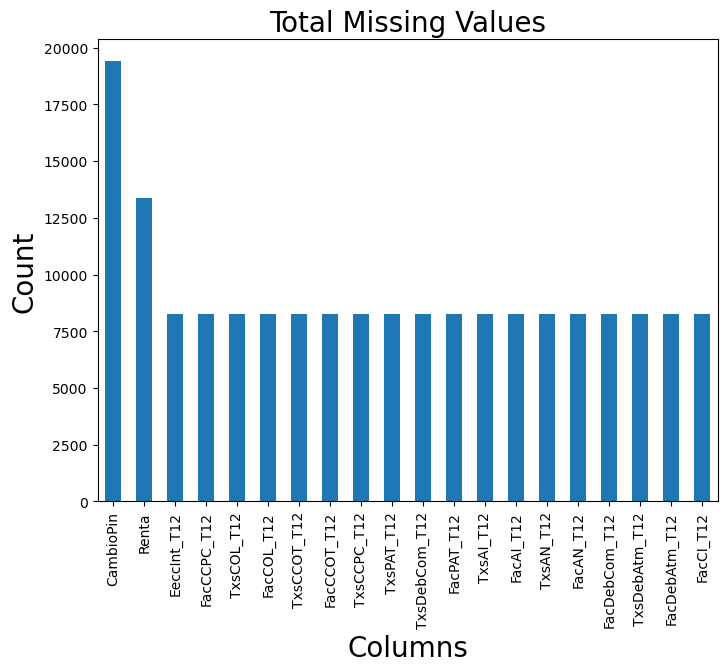

In [13]:
# Verificar los primeros 20 columnas con nan
total_nan = df.isnull().sum().sort_values(ascending = False)
total_select = total_nan.head(20)
total_select.plot(kind='bar', figsize=(8,6), fontsize=10)

plt.xlabel("Columns", fontsize = 20)
plt.ylabel("Count", fontsize = 20)
plt.title("Total Missing Values", fontsize = 20)
plt.show()

In [15]:
# verificar todos los nans
cols_nan = [[col, df[col].isna().sum()] for col in df.columns if df[col].isna().sum() > 0]
pd.DataFrame(cols_nan)

,0,1
0,Sexo,1
1,Region,53
2,Renta,13365
3,CambioPin,19388
4,FlgAct_T12,8251
...,...,...
494,EeccNac_T02,12
495,EeccInt_T02,12
496,UsoL1_T02,12
497,UsoL2_T02,12


# Exploración, Limpieza de datos y Feature Engineering

Recopilamos los datos correspondientes al primer trimestre del año. Estas columnas contienen información detallada sobre los promedios de facturación, la actividad comercial y el promedio de transacciones realizadas por los clientes durante los meses de enero, febrero y marzo. Este análisis nos permitirá obtener una visión completa del rendimiento de nuestras operaciones en este periodo específico del año, facilitando la toma de decisiones informadas y estratégicas.

In [18]:
# separacion de las columnnas importantes de facturaciones en una division trimestral desde enero a marzo

tri_01 = df[[
    'Fac_T01', 'Fac_T02', 'Fac_T03',          # Promedios de facturacion mensual de los clientes desde el mes 1 al 3
    'FlgAct_T01', 'FlgAct_T02', 'FlgAct_T03', # Actividad de los clientes desde el mes 1 al 3 
    'Txs_T01', 'Txs_T02', 'Txs_T03',          # Promedio de transacciones realizadas por los clientes desde el mes 1 al 3 
]]

Además, hemos incluido las siguientes columnas, las cuales considero esenciales para comprender a nuestros clientes y su comportamiento. Estas columnas son: sexo, edad, renta, región, antigüedad, internauta, CUPO_L1, cuenta corriente (Ctacte), débito, monoproducto y tarjeta de crédito (TC). Esta información nos permitirá realizar un análisis profundo y detallado de las características demográficas y financieras de nuestros clientes, lo cual es fundamental para desarrollar estrategias efectivas de marketing y mejorar la satisfacción del cliente.

In [20]:
# observaremos las siguientes dimensiones del data original
df_clas = (df[['Sexo', 'Edad', 'Renta', 'Region', 'Antiguedad', 'Internauta', 'CUPO_L1', 'Ctacte', 'Debito', 'Monoproducto', 'TC']])
df_clas.head()

,Sexo,Edad,Renta,Region,Antiguedad,Internauta,CUPO_L1,Ctacte,Debito,Monoproducto,TC
0,M,43,NaN,13.0,130,1,798000,1,1,0,3
1,H,46,143640.0,13.0,69,1,750000,1,0,0,1
2,H,45,929106.0,13.0,24,1,1350000,1,1,0,2
3,H,46,172447.0,13.0,134,0,1570800,0,0,1,2
4,H,46,805250.0,13.0,116,0,2762000,1,0,0,3


Para completar nuestro dataframe para nuestro objetivo de la clasificacion de churn y para mejorar la capacidad predictiva del modelo, se generaron nuevas variables basadas en patrones de uso y cambios en comportamiento.

### ✅ Facturación y Consumo

Suma_Facturacion y Promedio_Facturacion → Capturan el volumen total y promedio mensual de gasto.
Tasa_Cambio_Fact → Mide la variación en el consumo mes a mes.

### ✅ Frecuencia de Uso

Suma_Transacciones y Promedio_Transacciones → Número total y promedio de transacciones mensuales.
Tasa_Cambio_Txs → Identifica reducción en la cantidad de transacciones.

### ✅ Actividad del Cliente

Meses_Activo → Cuenta cuántos meses el cliente ha usado activamente su tarjeta.
Tasa_Cambio_Actividad → Detecta clientes que han dejado de usar productos recientemente.

In [30]:
# Facturación:
df_clas['Suma_Facturacion'] = tri_01[['Fac_T01', 'Fac_T02', 'Fac_T03']].sum(axis=1)
df_clas['Promedio_Facturacion'] = tri_01[['Fac_T01', 'Fac_T02', 'Fac_T03']].mean(axis=1)
df_clas['Tasa_Cambio_Fact'] = np.where(tri_01['Fac_T01'] != 0, 
                                       tri_01['Fac_T03'] / tri_01['Fac_T01'], 
                                       np.nan) -1 

# Transacciones:
df_clas['Suma_Transacciones'] = tri_01[['Txs_T01', 'Txs_T02', 'Txs_T03']].sum(axis=1)
df_clas['Promedio_Transacciones'] = tri_01[['Txs_T01', 'Txs_T02', 'Txs_T03']].mean(axis=1)
df_clas['Tasa_Cambio_Txs'] = np.where(tri_01['Txs_T01'] != 0, 
                                       tri_01['Txs_T03'] / tri_01['Txs_T01'], 
                                       np.nan) -1 

# Actividad:
df_clas['Meses_Activo'] = tri_01[['FlgAct_T01', 'FlgAct_T02', 'FlgAct_T03']].sum(axis=1)
df_clas['Tasa_Cambio_Actividad'] = np.where(tri_01['FlgAct_T01'] != 0, 
                                       tri_01['FlgAct_T03'] / tri_01['FlgAct_T01'], 
                                       np.nan) -1 

Definimos a los clientes "churn" como aquellos clientes que no han mostrado ninguna actividad durante los últimos dos meses consecutivos. Este criterio nos permite identificar a los clientes que, por diversas razones, han dejado de interactuar con nuestros productos o servicios. Al detectar a tiempo estos patrones de inactividad, podemos implementar estrategias de retención adecuadas para recuperar y reenganchar a estos clientes, asegurando así una mayor fidelización y satisfacción a largo plazo.

In [38]:
df_clas['Churn'] = ((tri_01['FlgAct_T03'] == 0) & (tri_01['FlgAct_T02'] == 0)).astype(int)

In [40]:
df_clas

,Sexo,Edad,Renta,Region,Antiguedad,Internauta,CUPO_L1,Ctacte,Debito,Monoproducto,TC,Suma_Facturacion,Promedio_Facturacion,Tasa_Cambio_Fact,Suma_Transacciones,Promedio_Transacciones,Tasa_Cambio_Txs,Meses_Activo,Tasa_Cambio_Actividad,Churn
0,M,43,NaN,13.0,130,1,798000,1,1,0,3,0.0,0.000000,NaN,0.0,0.000000,NaN,0.0,NaN,1
1,H,46,143640.0,13.0,69,1,750000,1,0,0,1,138218.0,46072.666667,-0.951982,3.0,1.000000,0.000000,3.0,0.0,0
2,H,45,929106.0,13.0,24,1,1350000,1,1,0,2,255915.0,85305.000000,-0.965244,10.0,3.333333,-0.333333,3.0,0.0,0
3,H,46,172447.0,13.0,134,0,1570800,0,0,1,2,46880.0,15626.666667,1.270816,3.0,1.000000,0.000000,3.0,0.0,0
4,H,46,805250.0,13.0,116,0,2762000,1,0,0,3,746406.0,248802.000000,0.370731,27.0,9.000000,-0.200000,3.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51119,H,51,364978.0,13.0,57,1,999000,1,1,0,3,146936.0,48978.666667,-0.361865,15.0,5.000000,0.000000,3.0,0.0,0
51120,H,51,625376.0,13.0,39,1,1744200,1,1,0,1,399672.0,133224.000000,7.391049,5.0,1.666667,2.000000,3.0,0.0,0
51121,H,47,806220.0,13.0,153,1,1061000,1,1,0,2,24259.0,8086.333333,NaN,1.0,0.333333,NaN,1.0,NaN,0
51122,M,47,NaN,13.0,11,1,1612000,1,0,0,1,159982.0,53327.333333,-0.770604,4.0,1.333333,-0.500000,3.0,0.0,0


In [42]:
df_clas['Churn'].value_counts()

Churn
0    42279
1     8845
Name: count, dtype: int64

Observamos que nuestra variable objetivo "Churn" está desbalanceada, ya que tenemos 42,279 clientes clasificados como 0 y 8,845 clientes clasificados como 1. Esta desproporción indica un desbalance significativo en nuestro conjunto de datos, lo cual podría afectar negativamente el rendimiento y la precisión de nuestros modelos predictivos. Es crucial abordar este desequilibrio para mejorar la calidad de nuestras predicciones y asegurarnos de que nuestros análisis reflejen con precisión el comportamiento real de nuestros clientes. Podemos considerar la aplicación de técnicas de balanceo de datos.

In [45]:
correlation = df_clas.corr(numeric_only= True)
churn_corr = correlation['Churn'].sort_values(ascending=False)
top_corr = churn_corr[abs(churn_corr) > 0.5]
top_corr

Churn                    1.000000
Tasa_Cambio_Actividad   -0.590244
Meses_Activo            -0.763730
Name: Churn, dtype: float64

Hemos identificado que las variables con mayor correlación con el "churn" son la tasa de cambio de actividad y los meses activos. Este hallazgo es significativo, ya que nos permite enfocar nuestros esfuerzos de análisis y estrategia en estas dos variables clave. La tasa de cambio de actividad refleja cómo varía la frecuencia de las interacciones de un cliente con nuestros productos o servicios, mientras que los meses activos indican el tiempo total que un cliente ha estado comprometido con nuestra marca. Al analizar y monitorear estas variables, podemos obtener información valiosa sobre los patrones de comportamiento de nuestros clientes

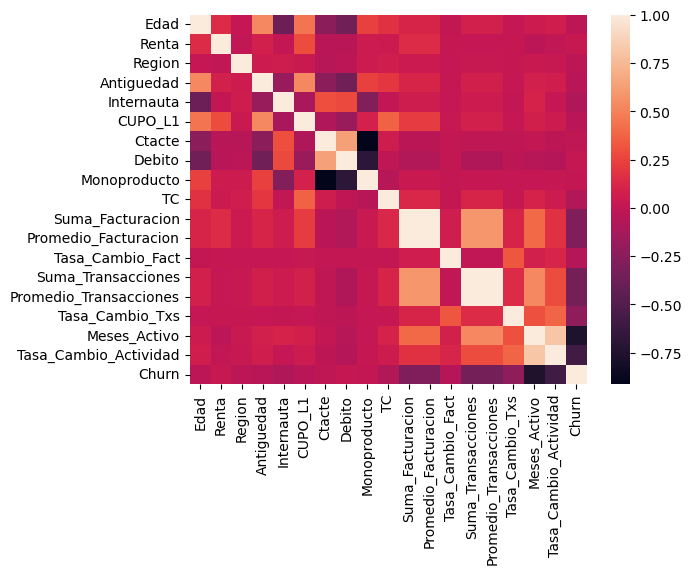

In [48]:
sns.heatmap(correlation)
plt.show()

#### Transformación e imputacion de nans

In [50]:
# transformamos nuestro variable categorica sexo con get_dummies
df_clas = pd.get_dummies(df_clas, columns=['Sexo'], dtype=int)

In [52]:
nans = [x for x in df_clas.columns if df_clas[x].isna().sum() > 0]
nans

['Renta',
 'Region',
 'Tasa_Cambio_Fact',
 'Tasa_Cambio_Txs',
 'Tasa_Cambio_Actividad']

In [56]:
# imputamos los nans de la lista que obtuvimos
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5, weights='distance', metric='nan_euclidean')

for column in nans:
    df_clas[[column]] = imputer.fit_transform(df_clas[[column]])

print(df_clas.isna().sum())

Edad                      0
Renta                     0
Region                    0
Antiguedad                0
Internauta                0
CUPO_L1                   0
Ctacte                    0
Debito                    0
Monoproducto              0
TC                        0
Suma_Facturacion          0
Promedio_Facturacion      0
Tasa_Cambio_Fact          0
Suma_Transacciones        0
Promedio_Transacciones    0
Tasa_Cambio_Txs           0
Meses_Activo              0
Tasa_Cambio_Actividad     0
Churn                     0
Sexo_H                    0
Sexo_M                    0
dtype: int64


In [58]:
df_clas.head()

,Edad,Renta,Region,Antiguedad,Internauta,CUPO_L1,Ctacte,Debito,Monoproducto,TC,...,Promedio_Facturacion,Tasa_Cambio_Fact,Suma_Transacciones,Promedio_Transacciones,Tasa_Cambio_Txs,Meses_Activo,Tasa_Cambio_Actividad,Churn,Sexo_H,Sexo_M
0,43,663077.078726,13.0,130,1,798000,1,1,0,3,...,0.000000,1.539435,0.0,0.000000,0.236879,0.0,-0.182342,1,0,1
1,46,143640.000000,13.0,69,1,750000,1,0,0,1,...,46072.666667,-0.951982,3.0,1.000000,0.000000,3.0,0.000000,0,1,0
2,45,929106.000000,13.0,24,1,1350000,1,1,0,2,...,85305.000000,-0.965244,10.0,3.333333,-0.333333,3.0,0.000000,0,1,0
3,46,172447.000000,13.0,134,0,1570800,0,0,1,2,...,15626.666667,1.270816,3.0,1.000000,0.000000,3.0,0.000000,0,1,0
4,46,805250.000000,13.0,116,0,2762000,1,0,0,3,...,248802.000000,0.370731,27.0,9.000000,-0.200000,3.0,0.000000,0,1,0


In [64]:
for col in df_clas.columns:
    if df_clas[col].dtype == 'float64':
        df_clas[col] = df_clas[col].astype('float32')
    if df_clas[col].dtype == 'int64':
        df_clas[col] = df_clas[col].astype('int32')

df_clas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51124 entries, 0 to 51123
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Edad                    51124 non-null  int32  
 1   Renta                   51124 non-null  float32
 2   Region                  51124 non-null  float32
 3   Antiguedad              51124 non-null  int32  
 4   Internauta              51124 non-null  int32  
 5   CUPO_L1                 51124 non-null  int32  
 6   Ctacte                  51124 non-null  int32  
 7   Debito                  51124 non-null  int32  
 8   Monoproducto            51124 non-null  int32  
 9   TC                      51124 non-null  int32  
 10  Suma_Facturacion        51124 non-null  float32
 11  Promedio_Facturacion    51124 non-null  float32
 12  Tasa_Cambio_Fact        51124 non-null  float32
 13  Suma_Transacciones      51124 non-null  float32
 14  Promedio_Transacciones  51124 non-null

In [66]:
df_clas.to_csv('DataFrame_for_classification.csv', index=False)

## Modelos de Clasificación

Procederemos a balancear nuestra variable "churn", ya que actualmente contamos con 42,279 registros clasificados como "no-churn" y 8,845 registros clasificados como "churn". Esta desproporción puede influir negativamente en la precisión y el rendimiento de nuestros modelos predictivos, al sesgar los resultados hacia la clase mayoritaria

In [153]:
ds = pd.read_csv('DataFrame_for_classification.csv')

In [155]:
ds

,Edad,Renta,Region,Antiguedad,Internauta,CUPO_L1,Ctacte,Debito,Monoproducto,TC,...,Promedio_Facturacion,Tasa_Cambio_Fact,Suma_Transacciones,Promedio_Transacciones,Tasa_Cambio_Txs,Meses_Activo,Tasa_Cambio_Actividad,Churn,Sexo_H,Sexo_M
0,43,663077.06,13.0,130,1,798000,1,1,0,3,...,0.0000,1.539435,0.0,0.000000,0.236879,0.0,-0.182342,1,0,1
1,46,143640.00,13.0,69,1,750000,1,0,0,1,...,46072.6680,-0.951982,3.0,1.000000,0.000000,3.0,0.000000,0,1,0
2,45,929106.00,13.0,24,1,1350000,1,1,0,2,...,85305.0000,-0.965244,10.0,3.333333,-0.333333,3.0,0.000000,0,1,0
3,46,172447.00,13.0,134,0,1570800,0,0,1,2,...,15626.6670,1.270816,3.0,1.000000,0.000000,3.0,0.000000,0,1,0
4,46,805250.00,13.0,116,0,2762000,1,0,0,3,...,248802.0000,0.370731,27.0,9.000000,-0.200000,3.0,0.000000,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51119,51,364978.00,13.0,57,1,999000,1,1,0,3,...,48978.6680,-0.361865,15.0,5.000000,0.000000,3.0,0.000000,0,1,0
51120,51,625376.00,13.0,39,1,1744200,1,1,0,1,...,133224.0000,7.391049,5.0,1.666667,2.000000,3.0,0.000000,0,1,0
51121,47,806220.00,13.0,153,1,1061000,1,1,0,2,...,8086.3335,1.539435,1.0,0.333333,0.236879,1.0,-0.182342,0,1,0
51122,47,663077.06,13.0,11,1,1612000,1,0,0,1,...,53327.3320,-0.770604,4.0,1.333333,-0.500000,3.0,0.000000,0,0,1


In [157]:
correlation = ds.corr(numeric_only= True)
churn_corr = correlation['Churn'].sort_values(ascending=False)
top_corr = churn_corr[abs(churn_corr) > 0.5]
top_corr

Churn           1.00000
Meses_Activo   -0.76373
Name: Churn, dtype: float64

In [159]:
important_columns = ds.copy() # [['Meses_Activo', 'Suma_Transacciones', 'Promedio_Transacciones', 'Tasa_Cambio_Actividad', 'Churn']]


X = important_columns.loc[ : , important_columns.columns != 'Churn']
y = important_columns['Churn']

<Axes: xlabel='Churn'>

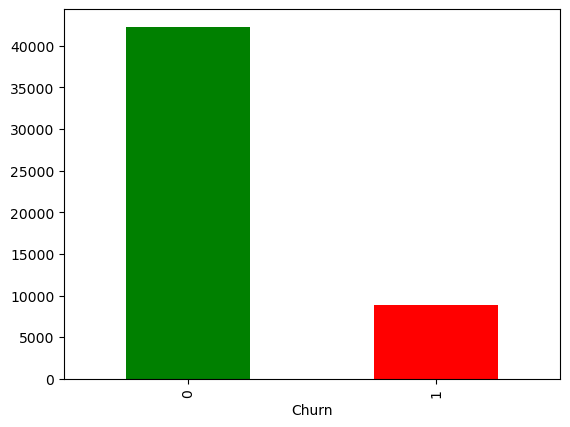

In [163]:
important_columns['Churn'].value_counts().plot.bar(color=['green', 'red'])

# Balancear Variable Churn con SMOTE

hacemos un shuffle stratificado de la variable y

In [169]:
target = 'Churn'
feature_cols = [x for x in important_columns.columns if x != target]

# Split the data into two parts with 1500 points in the test data
# This creates a generator
strat_shuff_split = StratifiedShuffleSplit(n_splits=2, test_size=0.3, random_state=123)

# Get the index values from the generator
train_idx, test_idx = next(strat_shuff_split.split(important_columns[feature_cols], important_columns[target]))

# Create the data sets
X_train = important_columns.loc[train_idx, feature_cols]
y_train = important_columns.loc[train_idx, target]

X_test = important_columns.loc[test_idx, feature_cols]
y_test = important_columns.loc[test_idx, target]

In [171]:
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

Churn
0    29595
1     6191
Name: count, dtype: int64
Churn
0    0.826999
1    0.173001
Name: proportion, dtype: float64


In [173]:
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))

Churn
0    12684
1     2654
Name: count, dtype: int64
Churn
0    0.826966
1    0.173034
Name: proportion, dtype: float64


Usamos el algoritmo de SMOTE para balancear la clase Churn

In [175]:
# Create a SMOTE sampler
smote_sampler = SMOTE(random_state = 123)

In [177]:
# Resample training data using SMOTE
X_smo, y_smo = smote_sampler.fit_resample(X_train, y_train)

In [183]:
X_smo

,Edad,Renta,Region,Antiguedad,Internauta,CUPO_L1,Ctacte,Debito,Monoproducto,TC,Suma_Facturacion,Promedio_Facturacion,Tasa_Cambio_Fact,Suma_Transacciones,Promedio_Transacciones,Tasa_Cambio_Txs,Meses_Activo,Tasa_Cambio_Actividad,Sexo_H,Sexo_M
0,47,1.340886e+06,7.000000,29,0,800000,1,1,0,2,152601.0,50867.000,1.169947,9.0,3.000000,1.000000,3.0,0.000000,0,1
1,27,4.175610e+05,1.000000,26,1,1600000,1,1,0,3,843325.0,281108.340,-0.979198,8.0,2.666667,-0.800000,3.0,0.000000,1,0
2,38,9.352420e+05,13.000000,31,0,1950000,0,0,1,1,356311.0,118770.336,0.525395,30.0,10.000000,0.625000,3.0,0.000000,0,1
3,32,4.155080e+05,13.000000,8,1,600000,1,1,0,2,124455.0,41485.000,-0.466453,10.0,3.333333,-0.571429,2.0,0.000000,1,0
4,32,1.500000e+05,13.000000,13,0,100000,0,0,1,1,0.0,0.000,1.539435,0.0,0.000000,0.236879,0.0,-0.182342,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59185,27,4.592963e+05,13.000000,9,1,200000,1,1,0,1,0.0,0.000,1.539435,0.0,0.000000,0.236879,0.0,-0.182342,0,1
59186,36,5.243575e+05,4.462751,33,1,1245935,1,1,0,1,0.0,0.000,1.539435,0.0,0.000000,0.236879,0.0,-0.182342,1,0
59187,31,5.675910e+05,13.000000,20,0,401091,1,1,0,1,0.0,0.000,1.539435,0.0,0.000000,0.236879,0.0,-0.182342,0,0
59188,45,6.891275e+05,13.000000,58,1,601873,1,1,0,1,0.0,0.000,1.539435,0.0,0.000000,0.236879,0.0,-0.182342,0,1


In [179]:
(X_smo.shape[0] - len(ds))

8066

<Axes: xlabel='Churn'>

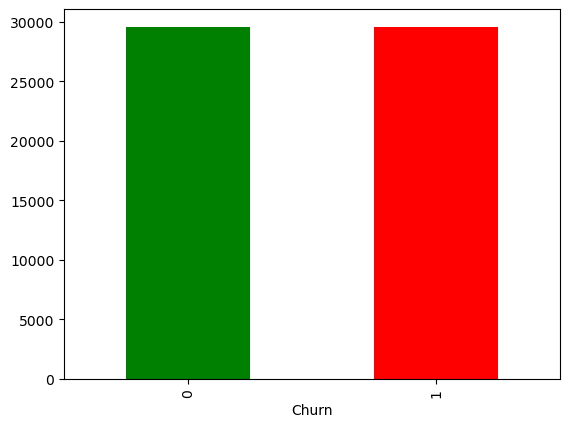

In [181]:
# Visualize classes
y_smo.value_counts().plot.bar(color=['green', 'red'])

### Escalar la variable X con MinMaxScaler

In [ ]:
from sklearn.preprocessing import MinMaxScaler
mm = MinMaxScaler()

In [185]:
X_smo2 = X_smo.copy()  # Para evitar modificar el original
for column in X_smo2.columns:
    X_smo2[column] = mm.fit_transform(X_smo2[[column]]) 

In [189]:
X_smo2.describe()

,Edad,Renta,Region,Antiguedad,Internauta,CUPO_L1,Ctacte,Debito,Monoproducto,TC,Suma_Facturacion,Promedio_Facturacion,Tasa_Cambio_Fact,Suma_Transacciones,Promedio_Transacciones,Tasa_Cambio_Txs,Meses_Activo,Tasa_Cambio_Actividad,Sexo_H,Sexo_M
count,59190.000000,59190.000000,59190.000000,59190.000000,59190.000000,59190.000000,59190.000000,59190.000000,59190.000000,59190.000000,59190.000000,59190.000000,59190.000000,59190.000000,59190.000000,59190.000000,59190.000000,59190.000000,59190.000000,59190.000000
mean,0.339701,0.051086,0.812241,0.098439,0.562747,0.050884,0.894915,0.843132,0.041612,0.072396,0.019499,0.019502,0.013323,0.024484,0.024487,0.165351,0.448692,0.736931,0.448809,0.369083
std,0.144147,0.028649,0.269539,0.103853,0.496051,0.049151,0.306666,0.363679,0.199702,0.098834,0.028449,0.028454,0.010163,0.041317,0.041318,0.028547,0.413733,0.336919,0.497377,0.482560
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.220930,0.035677,0.660126,0.025157,0.000000,0.018575,1.000000,1.000000,0.000000,0.000000,0.003521,0.003521,0.010809,0.000000,0.000000,0.152094,0.000000,0.817658,0.000000,0.000000
50%,0.302326,0.050658,1.000000,0.059748,1.000000,0.037151,1.000000,1.000000,0.000000,0.000000,0.008676,0.008676,0.013668,0.009524,0.009524,0.168564,0.333333,0.817658,0.000000,0.000000
75%,0.418605,0.054588,1.000000,0.141509,1.000000,0.068416,1.000000,1.000000,0.000000,0.125000,0.024408,0.024413,0.013668,0.033333,0.033333,0.168564,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Regresión Logistica

In [191]:
# Re-train the model with resampled data
lr = LogisticRegression(random_state=123, 
                        max_iter = 1000)
lr.fit(X_smo2, y_smo)
lr_preds = lr.predict(X_test)

In [193]:
accuracy_score(y_test, lr_preds)

0.322075889946538

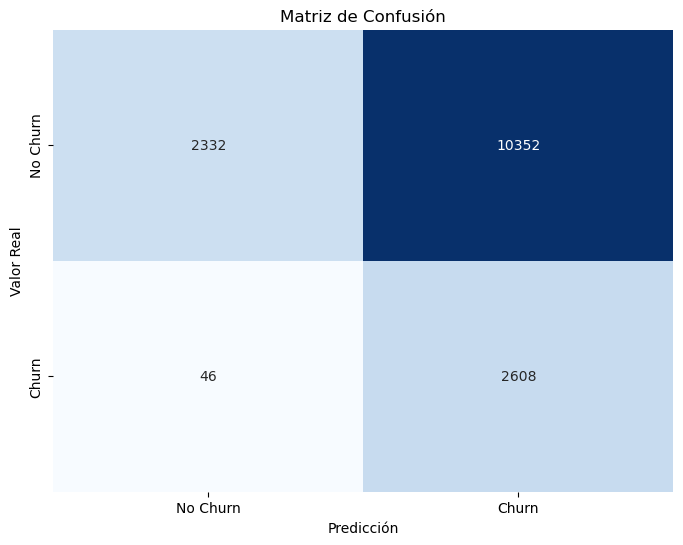

-------------------------------------------------
              precision    recall  f1-score   support

           0       0.98      0.18      0.31     12684
           1       0.20      0.98      0.33      2654

    accuracy                           0.32     15338
   macro avg       0.59      0.58      0.32     15338
weighted avg       0.85      0.32      0.31     15338

-------------------------------------------------
Curva de roc y area bajo la curva
0.5832606726796179


In [293]:
get_metricas(y_test, lr_preds)

balancear la variable "churn" mejora la capacidad del modelo para detectar casos de churn, aunque puede afectar levemente la precisión general.

# Algorítmo de árbol de decisión

In [197]:
dt_model = DecisionTreeClassifier(random_state=123)

In [199]:
dt_model.fit(X_smo2, y_smo.values.ravel())

DecisionTreeClassifier(random_state=123)

In [201]:
y_pred = dt_model.predict(X_test)

In [205]:
evaluate_metrics(y_test, y_pred)

{'accuracy': 0.9503194679880036,
 'recall': 0.7143933685003768,
 'precision': 0.9978947368421053,
 'f1score': 0.8326745718050066}

In [209]:
feature_names = important_columns.loc[ : , important_columns.columns != 'Churn']

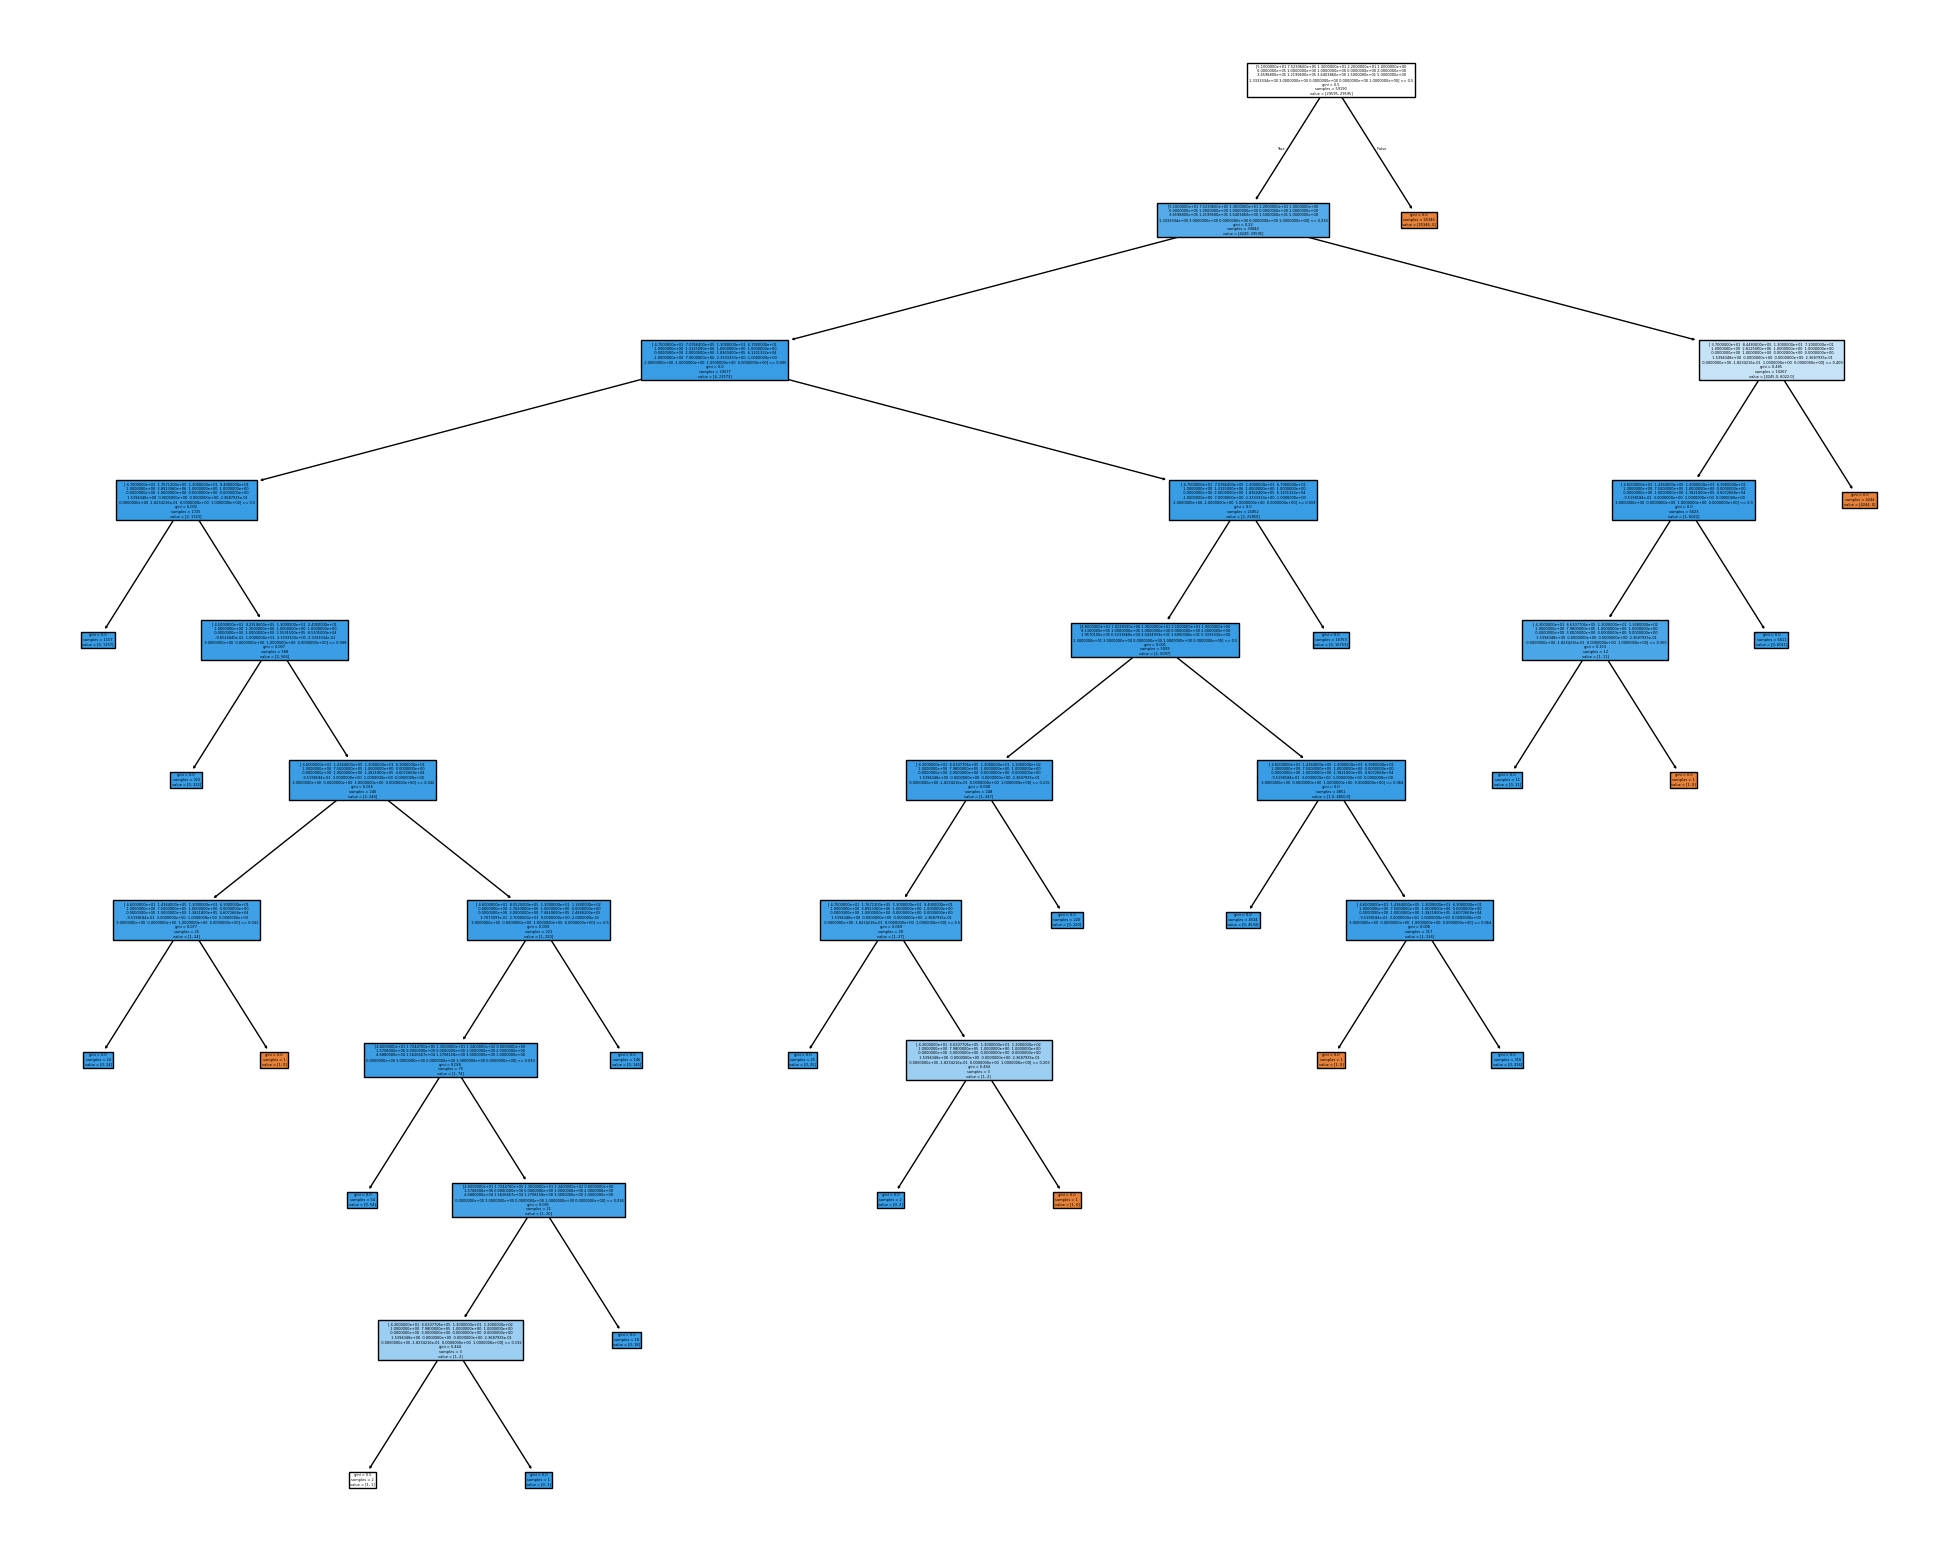

In [211]:
plot_decision_tree(dt_model, feature_names.values)

## Arbol de decision customizado

In [221]:
params_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 5, 10, 15]
}

In [223]:
model = DecisionTreeClassifier(random_state=123)

In [225]:
grid_search = GridSearchCV(estimator = model, 
                           param_grid = params_grid, 
                           scoring='f1',
                           cv = 5, 
                           verbose = 1)

grid_search.fit(X_smo2, y_smo.values.ravel())
best_params = grid_search.best_params_

Fitting 5 folds for each of 40 candidates, totalling 200 fits


In [227]:
best_params

{'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 5}

In [229]:
dt_best_model = DecisionTreeClassifier(criterion='gini', max_depth= 5, min_samples_leaf= 5, random_state=123)

In [231]:
dt_best_model.fit(X_smo2, y_smo.values.ravel())

DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=123)

In [233]:
y_best_model_pred = dt_best_model.predict(X_test)

In [235]:
evaluate_metrics(y_test, y_best_model_pred)

{'accuracy': 0.9503194679880036,
 'recall': 0.7143933685003768,
 'precision': 0.9978947368421053,
 'f1score': 0.8326745718050066}

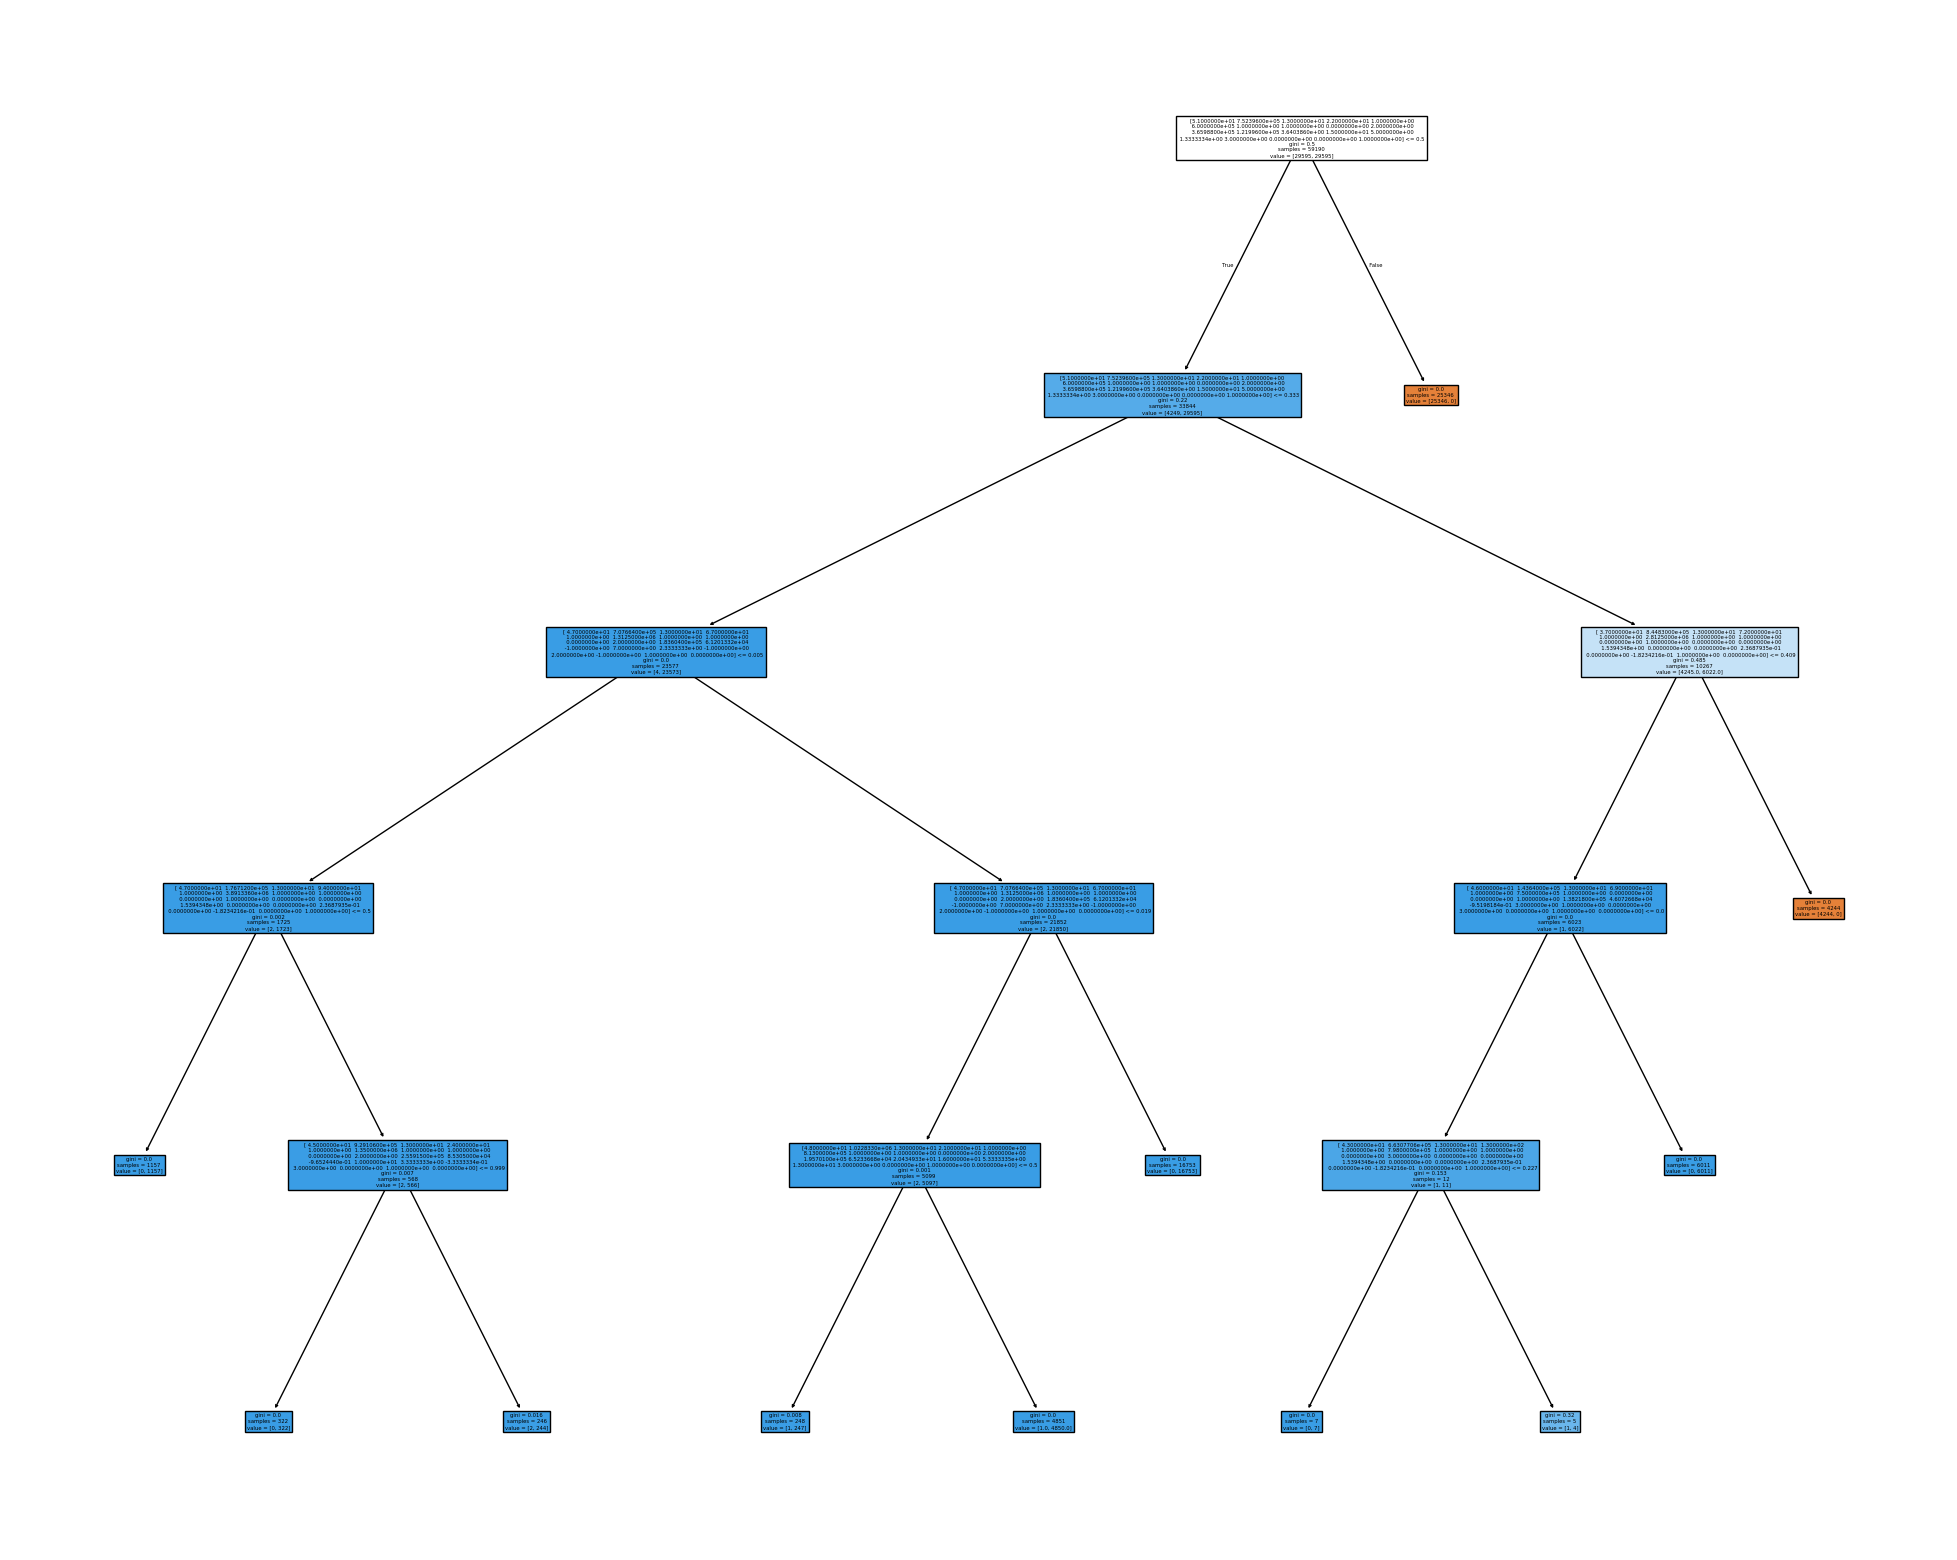

In [237]:
plot_decision_tree(dt_best_model, feature_names.values)

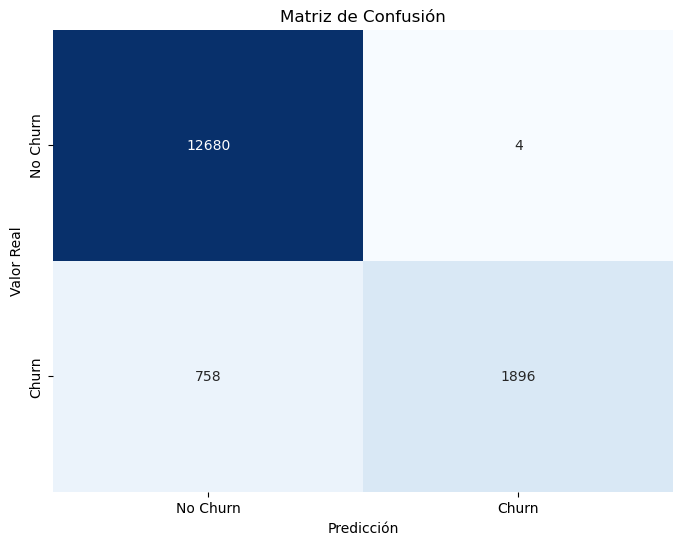

-------------------------------------------------
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     12684
           1       1.00      0.71      0.83      2654

    accuracy                           0.95     15338
   macro avg       0.97      0.86      0.90     15338
weighted avg       0.95      0.95      0.95     15338

-------------------------------------------------
Curva de roc y area bajo la curva
0.8570390052845624


In [295]:
get_metricas(y_test, y_best_model_pred)

# KNN Classifier

In [245]:
knn = KNeighborsClassifier(n_neighbors=5)

In [247]:
knn = knn.fit(X_smo2, y_smo)

In [249]:
y_pred_knn = knn.predict(X_test)

In [251]:
evaluate_metrics(y_test, y_pred_knn)

{'accuracy': 0.6254400834528622,
 'recall': 0.49924642049736245,
 'precision': 0.23079602856645184,
 'f1score': 0.3156640857653365}

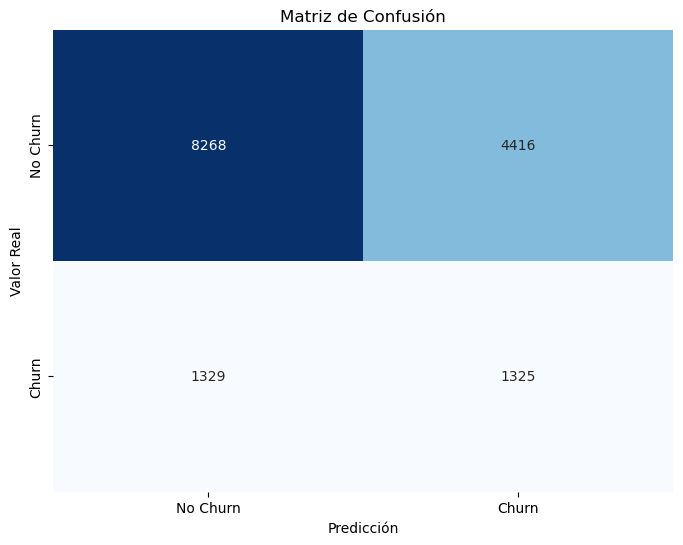

-------------------------------------------------
              precision    recall  f1-score   support

           0       0.86      0.65      0.74     12684
           1       0.23      0.50      0.32      2654

    accuracy                           0.63     15338
   macro avg       0.55      0.58      0.53     15338
weighted avg       0.75      0.63      0.67     15338

-------------------------------------------------
Curva de roc y area bajo la curva
0.5755456321975932


In [297]:
get_metricas(y_test, y_pred_knn)

In [255]:
max_k = 40
f1_scores = list()
error_rates = list() # 1-accuracy

for k in range(1, max_k):
    
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn = knn.fit(X_smo2, y_smo)
    
    y_pred = knn.predict(X_test)
    f1 = f1_score(y_pred, y_test)
    f1_scores.append((k, round(f1_score(y_test, y_pred), 4)))
    error = 1-round(accuracy_score(y_test, y_pred), 4)
    error_rates.append((k, error))
    
f1_results = pd.DataFrame(f1_scores, columns=['K', 'F1 Score'])
error_results = pd.DataFrame(error_rates, columns=['K', 'Error Rate'])

In [273]:
f1_results.describe()

,K,F1 Score
count,39.000000,39.000000
mean,20.000000,0.335403
std,11.401754,0.022976
min,1.000000,0.283900
25%,10.500000,0.317000
50%,20.000000,0.347500
75%,29.500000,0.350250
max,39.000000,0.363400


In [275]:
error_results.describe()

,K,Error Rate
count,39.000000,39.000000
mean,20.000000,0.508297
std,11.401754,0.123822
min,1.000000,0.347400
25%,10.500000,0.372450
50%,20.000000,0.570800
75%,29.500000,0.627950
max,39.000000,0.642300


# Comparación de Modelos para la Predicción de Churn

Se evaluaron tres modelos de clasificación para predecir la fuga de clientes: Regresión Logística, Árbol de Decisión con GridSearchCV y K-Nearest Neighbors (KNN). La comparación se basó en métricas clave como F1-score, precisión, recall, accuracy y área bajo la curva ROC (AUC-ROC).

El modelo de Regresión Logística mostró un recall alto (0.98) en la clase churn, lo que significa que detecta casi todos los clientes que se van, pero su precisión fue muy baja (0.20), indicando que genera demasiados falsos positivos. Esto resultó en un F1-score de apenas 0.33 para la clase churn y un ROC-AUC de 0.58, lo que sugiere que el modelo no separa bien las clases.

Por otro lado, el Árbol de Decisión con GridSearchCV presentó un rendimiento significativamente superior, con una precisión perfecta (1.00) para la clase churn y un recall de 0.71, lo que permite detectar una gran cantidad de clientes en riesgo sin generar tantos falsos positivos. Su F1-score de 0.83 y ROC-AUC de 0.86 demuestran que el modelo logra un buen balance entre identificar correctamente la fuga de clientes y minimizar errores. Además, su accuracy general fue de 95%, reflejando una alta capacidad predictiva.

En cuanto al KNN Classifier, su rendimiento fue inferior a los otros dos modelos. Aunque logró un accuracy moderado de 0.63, su F1-score para la clase churn fue de solo 0.32, con una precisión de 0.23 y un recall de 0.50. Además, su ROC-AUC fue el más bajo (0.57), lo que indica que no separa bien las clases. Esto sugiere que KNN no es una opción adecuada para este problema.

# Conclusión y Recomendaciones

Dado su mejor rendimiento en todas las métricas clave, el Árbol de Decisión con GridSearchCV es el modelo más adecuado para la predicción de churn y, por lo tanto, el que se debería utilizar. Su alto F1-score y AUC-ROC indican que puede identificar correctamente los clientes en riesgo sin generar demasiados falsos positivos, lo que lo hace útil para tomar decisiones estratégicas en la retención de clientes.

Para garantizar que el modelo se mantenga bien entrenado y relevante a lo largo del tiempo, se recomienda implementar un proceso de monitoreo y actualización periódica. Algunas estrategias clave incluyen:

- Reentrenamiento del modelo con datos nuevos cada cierto tiempo para adaptarlo a posibles cambios en el comportamiento de los clientes.
- Monitoreo de métricas de desempeño en producción para detectar posibles deterioros en la precisión del modelo.
- Ajuste de hiperparámetros periódicamente mediante GridSearchCV para optimizar su rendimiento.
- Exploración de modelos más avanzados, como Random Forest o XGBoost, que podrían mejorar aún más la precisión y robustez del modelo.
- Incorporación de nuevas variables o características que puedan aportar más información relevante sobre el comportamiento de los clientes.

Siguiendo estas recomendaciones, el modelo podrá mantenerse actualizado y seguir proporcionando predicciones confiables para la toma de decisiones estratégicas en la retención de clientes.